In [1]:
import os
import glob
from enum import Enum

import torch
from torchvision.ops import box_iou

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [3]:
STORAGE_DIR = "/mnt/ex_ssd/starcraft-vision"

DATA_DIR = os.path.join(STORAGE_DIR, "data")
GROUND_TRUTH_DIR = os.path.join(DATA_DIR, "label", "dst")
PREDICTIONS_DIR = os.path.join(STORAGE_DIR, "predictions")

In [54]:
REPLAYS = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep', '6254.rep']
# REPLAYS = ['1559.rep', '1628.rep', '2351.rep', '6219.rep', '11251.rep']

In [55]:
INFERENCE_MODEL_VANILLA = "all_correct_win4_b8_20250815_073611/model_14"

In [56]:
ground_truth_json_path = [
    f for name in REPLAYS
    for f in glob.glob(os.path.join(GROUND_TRUTH_DIR, name, '*.json'))
]

In [57]:
def read_json_files(directory, label_method='all_correct', replays=None):
    data = []

    if replays:
        targets = [os.path.join(rep, f"{label_method}.json") for rep in replays]
    else:
        targets = os.listdir(directory)

    for filename in targets:
        if filename.endswith(".json"):
            filepath = os.path.join(directory, filename)
            if os.path.isfile(filepath):
                with open(filepath, "r", encoding="utf-8") as f:
                    data.append(json.load(f))

    return data

In [58]:
ground_truth_data = read_json_files(GROUND_TRUTH_DIR, label_method='all_correct', replays=REPLAYS)

In [59]:
prediction_data = read_json_files(os.path.join(PREDICTIONS_DIR, INFERENCE_MODEL_VANILLA), label_method='all_correct', replays=REPLAYS)

In [60]:
def get_annotations(data, replay_suffix=".rep"):
    frames = []

    for item in (data or []):
        anns = item.get("annotations", [])
        if not anns:
            continue

        df = pd.DataFrame(anns)

        desc = (item.get("info") or {}).get("description", "") or ""
        replay_id = None
        if isinstance(desc, str) and desc.strip():
            replay_id = desc.strip().split()[-1]

        if replay_id is None:
            replay_id = "unknown"

        if replay_suffix and not str(replay_id).endswith(replay_suffix):
            replay_id = f"{replay_id}{replay_suffix}"

        df["replay"] = replay_id
        frames.append(df)

    base_cols = ["replay", "id", "image_id", "category_id", "bbox", "area", "segmentation", "iscrowd"]
    if not frames:
        return pd.DataFrame(columns=base_cols + ["score"])

    has_score = any("score" in f.columns for f in frames)

    wanted_cols = base_cols + (["score"] if has_score else [])
    for i, f in enumerate(frames):
        for col in wanted_cols:
            if col not in f.columns:
                frames[i][col] = pd.NA

    annotations = pd.concat(frames, ignore_index=True)

    return annotations[wanted_cols]

In [61]:
annotation_ground_truth = get_annotations(ground_truth_data)
annotation_prediction = get_annotations(prediction_data)

In [62]:
def dataframe_topk_score(dataframe, K=1):
    topk_df = (
      dataframe.sort_values('score', ascending=False)
        .groupby(['replay', 'image_id'], group_keys=False)
        .head(K)
    )
    return topk_df.sort_values(['replay', 'image_id'])

In [63]:
top1_annotation_prediction = dataframe_topk_score(annotation_prediction, 1)

In [64]:
annotation_ground_truth["idx"] = annotation_ground_truth.groupby(["replay", "image_id"]).cumcount()  # 0~4 인덱스 생성
wide_ground_truth = annotation_ground_truth.pivot(index=["replay", "image_id"], columns="idx", values="bbox")
wide_ground_truth.columns = [f"gt_{i}" for i in wide_ground_truth.columns]
wide_ground_truth.reset_index(inplace=True)


In [65]:
top1_annotation_prediction["idx"] = top1_annotation_prediction.groupby(["replay", "image_id"]).cumcount()  # 0~4 인덱스 생성
wide_prediction = top1_annotation_prediction.pivot(index=["replay", "image_id"], columns="idx", values="bbox")
wide_prediction.columns = [f"pred_{i}" for i in wide_prediction.columns]
wide_prediction.reset_index(inplace=True)

In [66]:
wide_ground_truth.head()

,replay,image_id,gt_0,gt_1,gt_2,gt_3,gt_4
0,1660.rep,0,"[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]"
1,1660.rep,1,"[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]"
2,1660.rep,2,"[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]"
3,1660.rep,3,"[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 1, 20, 12]","[108, 2, 20, 12]"
4,1660.rep,4,"[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 2, 20, 12]","[108, 1, 20, 12]","[108, 2, 20, 12]"


In [68]:
result_inference = pd.merge(wide_ground_truth, wide_prediction,on=["replay", "image_id"], how="outer")
result_inference.bfill(inplace=True)


In [ ]:
import numpy as np
import pandas as pd

def add_gt_union_metrics(
    df: pd.DataFrame,
    gt_cols = ("gt_0","gt_1","gt_2","gt_3","gt_4"),
    pred_col = "pred_0",
    grid_w = 128, grid_h = 128,
    kernel_x = 20, kernel_y = 12,
    use_bbox_size = False,   # True면 각 (x,y,w,h)의 w,h 사용, False면 고정 kernel_x,kernel_y
    thresholds = (0.0, 0.3, 0.5),
):
    def _clip(v, lo, hi):  # hi 포함 클립 (슬라이스 끝값 안전 보정에서 사용)
        return lo if v < lo else hi if v > hi else v

    def _xywh_to_rect(x, y, w, h):
        if not use_bbox_size:
            w, h = kernel_x, kernel_y
        # 좌상단 고정, 클리핑
        x = int(_clip(int(np.round(x)), 0, grid_w - 1))
        y = int(_clip(int(np.round(y)), 0, grid_h - 1))
        x2 = _clip(x + int(np.round(w)), 0, grid_w)
        y2 = _clip(y + int(np.round(h)), 0, grid_h)
        w2 = max(1, x2 - x)
        h2 = max(1, y2 - y)
        return x, y, w2, h2

    # 결과 버퍼
    ovls, ious, dices, crs, multi = [], [], [], [], []

    # 행 단위 처리 (union은 다중 사각형의 면적합/교집합을 정확하게 구하기 어렵기 때문에 rasterization이 가장 간단/안전)
    for row in df.itertuples(index=False):
        # --- 캔버스에 GT 합집합 누적 ---
        canvas = np.zeros((grid_h, grid_w), dtype=np.int16)

        for col in gt_cols:
            bx = getattr(row, col)
            if bx is None or (isinstance(bx, float) and np.isnan(bx)):  # 결측 방어
                continue
            x, y, w, h = (bx if len(bx) == 4 else tuple(bx)[:4])
            # 이미 그리드 좌표라 가정; (x_max,y_max) 스케일링이 필요하면 여기에 적용
            rx, ry, rw, rh = _xywh_to_rect(x, y, w, h)
            canvas[ry:ry+rh, rx:rx+rw] += 1

        union = (canvas > 0)

        # --- pred 패치 생성 ---
        pb = getattr(row, pred_col)
        x, y, w, h = (pb if len(pb) == 4 else tuple(pb)[:4])
        px, py, pw, ph = _xywh_to_rect(x, y, w, h)

        # 다중 교차 강도: pred 패치에서 GT 카운트 평균
        pred_counts = canvas[py:py+ph, px:px+pw]
        intersect_multi = float(pred_counts.mean()) if pred_counts.size else 0.0
        multi.append(intersect_multi)

        # 지표 계산
        patch = np.zeros_like(union, dtype=bool)
        patch[py:py+ph, px:px+pw] = True

        I  = np.logical_and(patch, union).sum()
        Ap = patch.sum()
        Ar = union.sum()
        U  = Ap + Ar - I

        ovl  = (I / Ap) if Ap > 0 else 0.0           # precision 유사 (사용 지표)
        iou  = (I / U ) if U  > 0 else 0.0           # 대칭형
        dice = (2*I/(Ap+Ar)) if (Ap+Ar) > 0 else 0.0 # 대칭형
        cr   = (I / Ar) if Ar > 0 else 0.0           # recall 유사

        ovls.append(ovl); ious.append(iou); dices.append(dice); crs.append(cr)

    # 컬럼 추가
    df = df.copy()
    df["union_ovl"]  = ovls
    df["union_iou"]  = ious
    df["union_dice"] = dices
    df["union_cr"]   = crs
    df["intersect_multi"] = multi

    # 임계값 플래그: thr==0 → (>0), 그 외 → (>=thr)
    for thr in thresholds:
        col = f"hit_at_{int(round(thr*100)):03d}"
        if thr == 0.0:
            df[col] = (df["union_ovl"] > 0.0)
        else:
            df[col] = (df["union_ovl"] >= thr)
        # 0/1 원하시면 다음 줄 추가:
        # df[col] = df[col].astype(int)

    return df


In [74]:

result_inference = add_gt_union_metrics(
    result_inference,
    gt_cols=("gt_0","gt_1","gt_2","gt_3","gt_4"),
    pred_col="pred_0",
    grid_w=128, grid_h=128,
    kernel_x=20, kernel_y=12,
    use_bbox_size=False,          # 고정 커널 20x12 (legacy 평가와 동일)
    thresholds=(0.0, 0.3, 0.5)
)

# 리플레이별 집계 예시
summary = (result_inference
           .groupby("replay")
           .agg(OVL_mean=("union_ovl","mean"),
                IC_at_030=("hit_at_030","mean"),
                IC_at_050=("hit_at_050","mean"))
           .reset_index())
print(summary.head())

     replay  OVL_mean  IC_at_030  IC_at_050
0  1660.rep  0.964337   0.998239   0.998201
1   212.rep  0.966444   0.999257   0.999257
2    36.rep  0.969799   0.998941   0.998835
3   438.rep  0.968090   0.998700   0.998700
4   522.rep  0.970783   0.999247   0.999247


In [145]:
def draw_overview(row):
    plt.figure(figsize=(6, 6), dpi=300)

    plt.imshow(np.zeros((128, 128)), vmin=0, vmax=1)

    ax = plt.gca()

    ax.set_xlim(0, 127)
    ax.set_ylim(127, 0)

    for i in range(5):
        x, y, w, h = tuple(getattr(row, f"gt_{i}"))
        rect = patches.Rectangle(
            (x, y),
            20,
            12,
            linewidth=1,
            edgecolor='green',
            linestyle='-',
            facecolor='none'
        )
        ax.add_patch(rect)

    x, y, w, h = tuple(getattr(row, "pred_0"))
    rect = patches.Rectangle(
        (x, y),
        20,
        12,
        linewidth=1,
        edgecolor='red',
        linestyle='--',
        facecolor='none'
    )
    ax.add_patch(rect)
        
    plt.title(f"{row['replay']} - Frame {row['image_id']}", fontsize=10, pad=5, loc='center')
    # plt.axis('off')
    plt.tight_layout()
    plt.show()


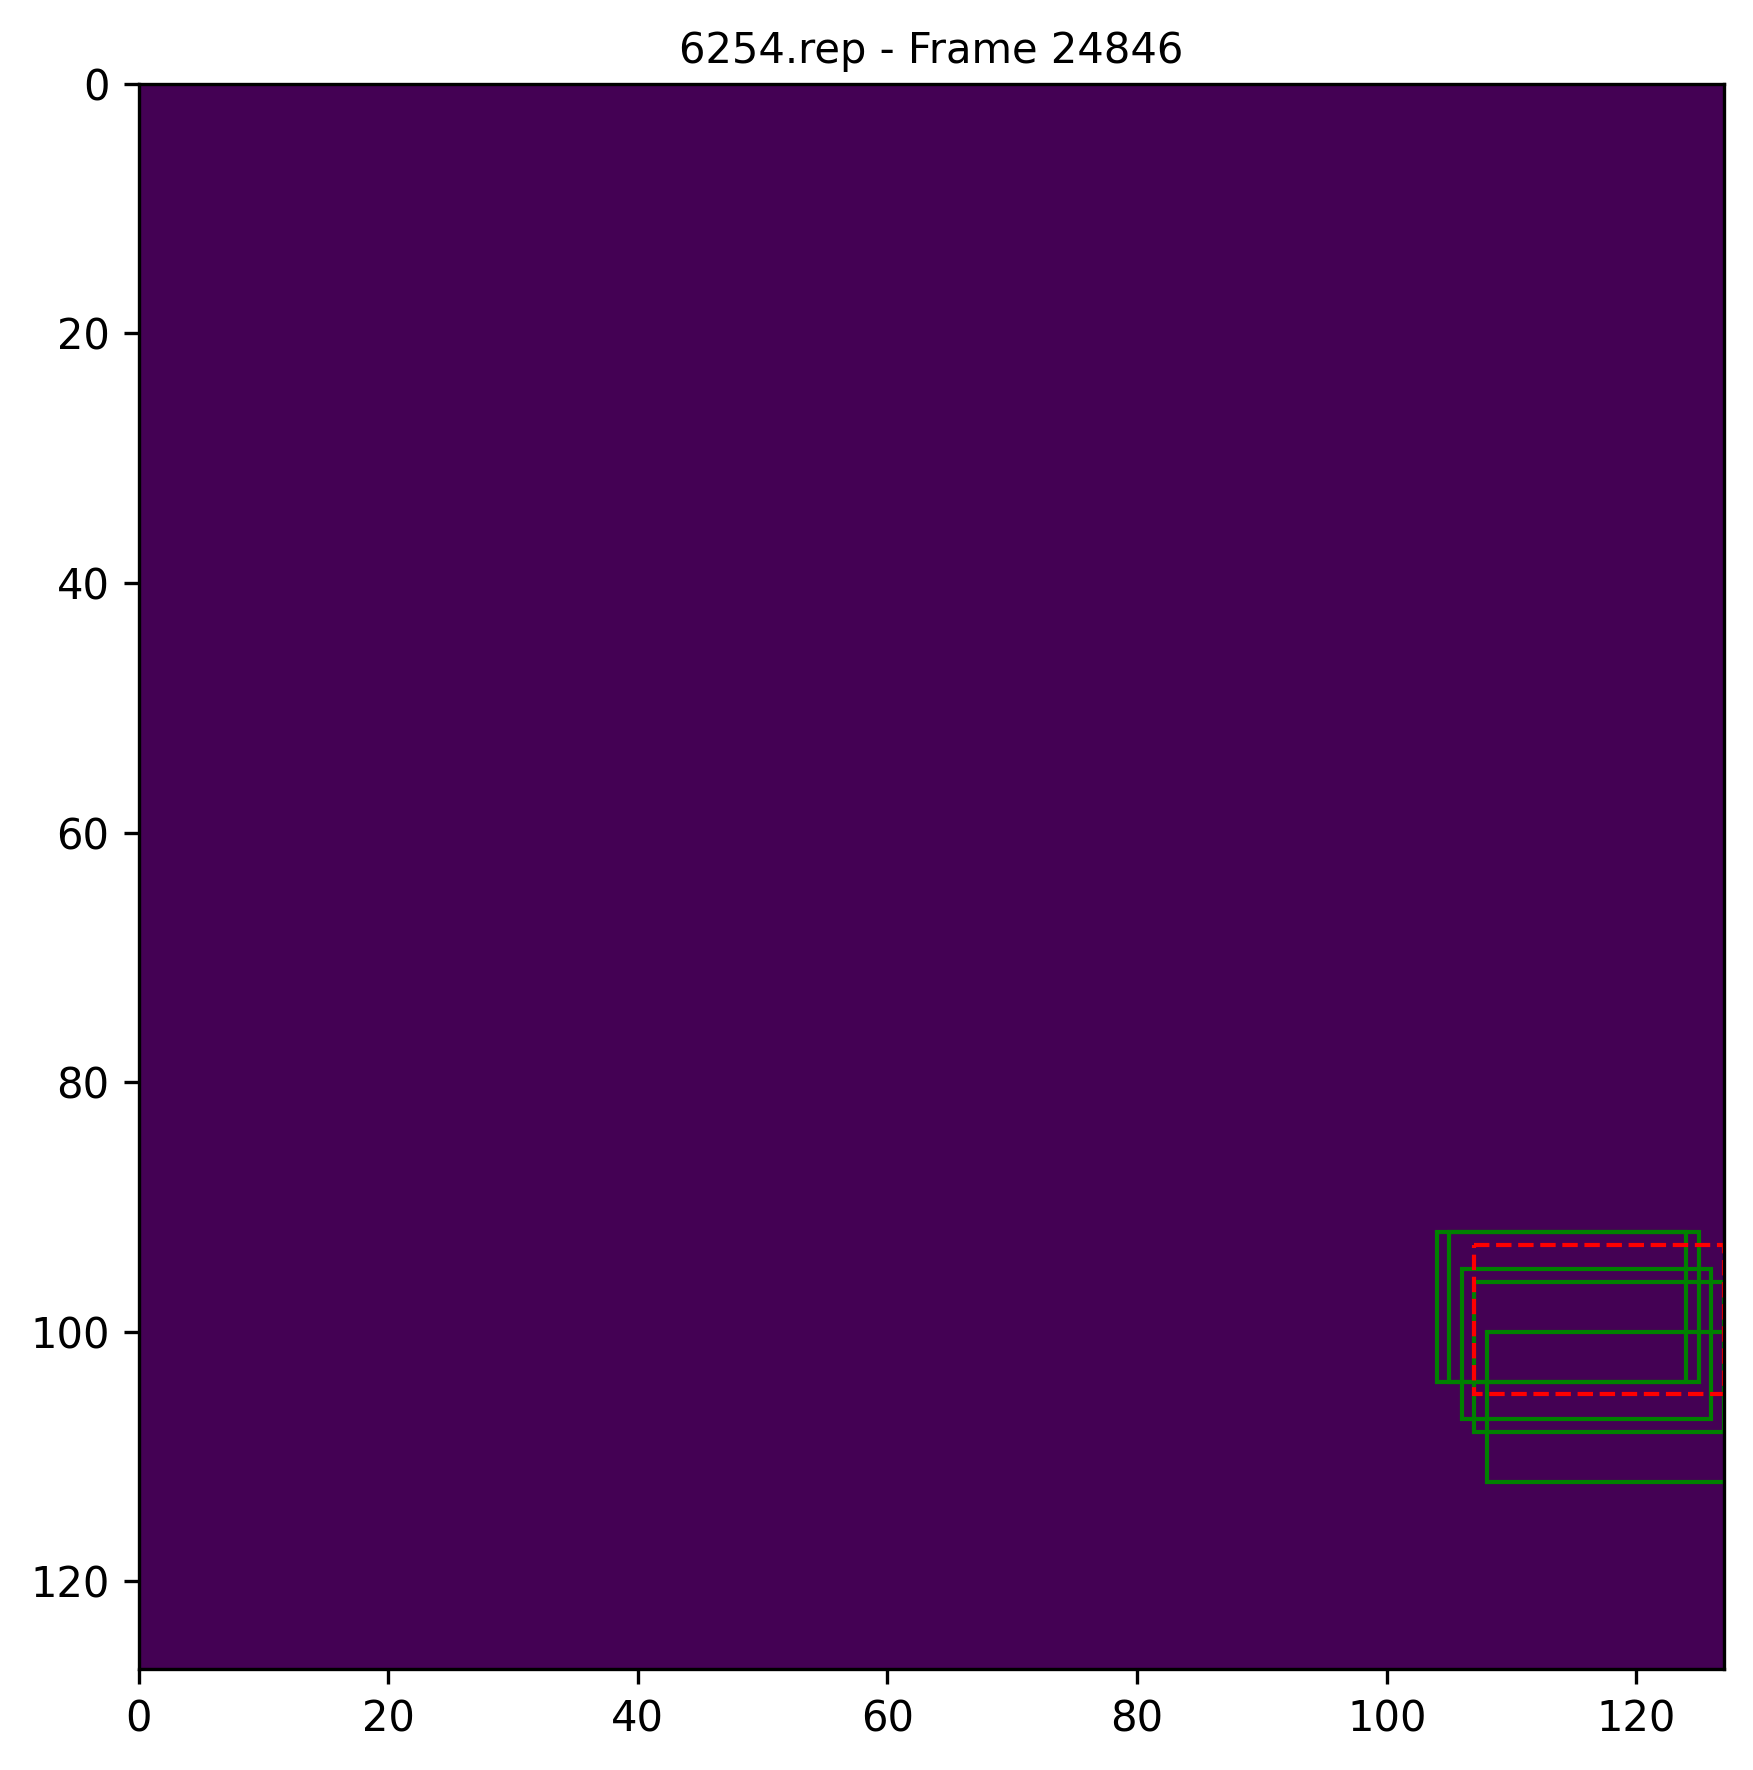

In [154]:
draw_overview(result_inference.iloc[165424])